In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

In [47]:
df = pd.read_csv("events.csv", nrows=100000)

In [49]:
df.head()
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     100000 non-null  object 
 1   event_type     100000 non-null  object 
 2   product_id     100000 non-null  int64  
 3   category_id    100000 non-null  int64  
 4   category_code  67413 non-null   object 
 5   brand          85607 non-null   object 
 6   price          100000 non-null  float64
 7   user_id        100000 non-null  int64  
 8   user_session   100000 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 6.9+ MB


event_time           0
event_type           0
product_id           0
category_id          0
category_code    32587
brand            14393
price                0
user_id              0
user_session         0
dtype: int64

In [51]:
# Convert time
df['event_time'] = pd.to_datetime(df['event_time'])

# Extract features
df['hour'] = df['event_time'].dt.hour
df['day'] = df['event_time'].dt.day

# Remove duplicates
df.drop_duplicates(inplace=True)

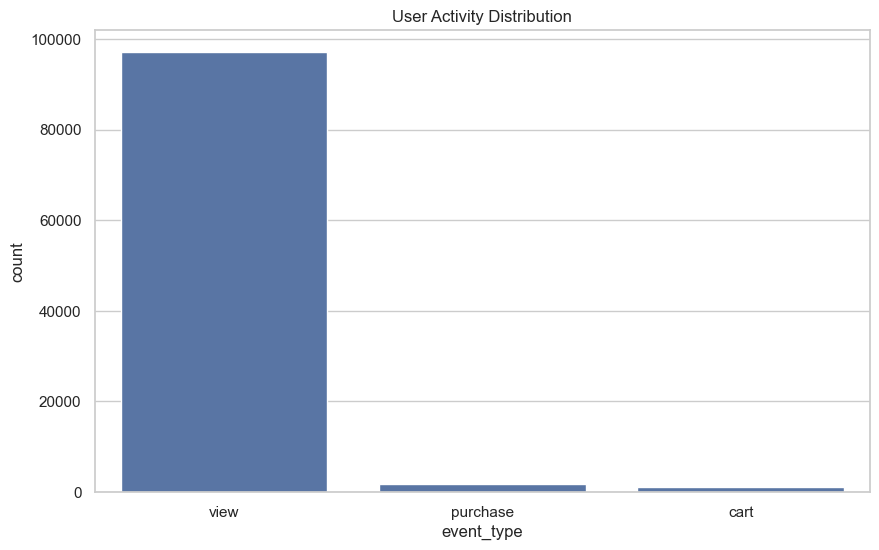

In [53]:
sns.countplot(data=df, x='event_type')
plt.title("User Activity Distribution")
plt.show()

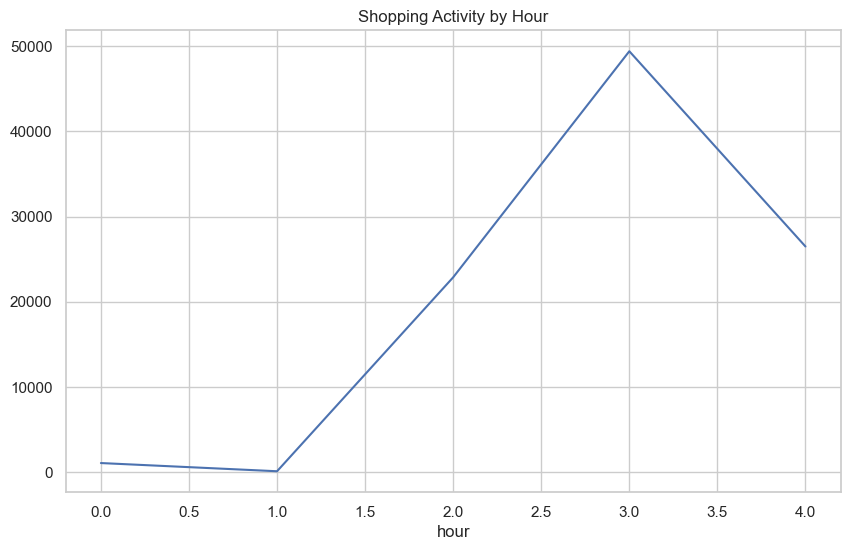

In [55]:
df['hour'].value_counts().sort_index().plot()
plt.title("Shopping Activity by Hour")
plt.show()

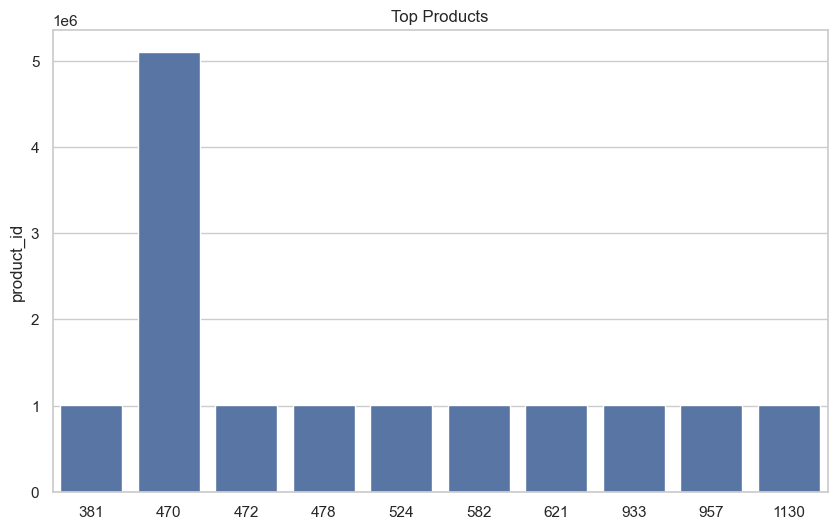

In [57]:
top_products = df['product_id'].value_counts().head(10)

sns.barplot(x=top_products.values, y=top_products.index)
plt.title("Top Products")
plt.show()

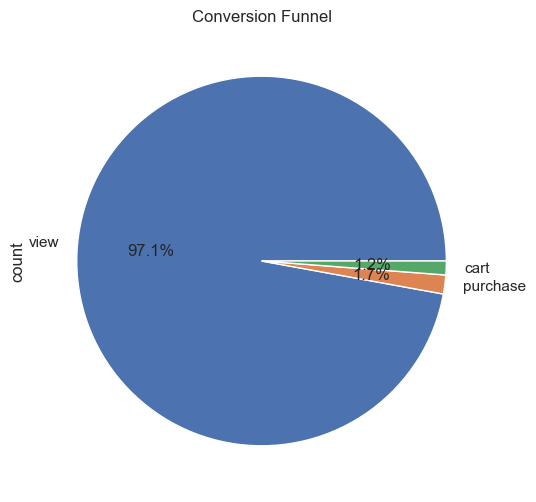

In [59]:
df['event_type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Conversion Funnel")
plt.show()

In [61]:
df['event_type_encoded'] = df['event_type'].map({
    'view': 0,
    'cart': 1,
    'purchase': 2
})

In [63]:
df_small = df.sample(20000)

df_small = df_small[['user_id', 'product_id', 'event_type_encoded']]

In [65]:
user_product = pd.crosstab(df_small['user_id'], df_small['product_id'])

In [67]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(user_product)

In [69]:
def recommend_products(user_index, top_n=5):
    scores = list(enumerate(similarity[user_index]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:top_n+1]

    similar_users = [i[0] for i in scores]

    recommended = user_product.iloc[similar_users].sum().sort_values(ascending=False)

    return recommended.head(top_n)

In [71]:
recommend_products(0)

product_id
1004751    1
6000072    1
4700546    1
1600282    1
4803981    1
dtype: int64